In [2]:
%pip install pandas numpy matplotlib seaborn

146.47s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys

print(sys.executable)
print(sys.version)

/usr/local/python/3.14.2/bin/python
3.14.2 (main, Aug 27 2026, 12:34:32) [GCC 13.3.0]


In [4]:
import pandas as pd
import numpy as np

# 1. Chargement
df = pd.read_csv('owid-energy-data.csv')

# 2. Sélection des colonnes (On vérifie qu'elles existent dans ton fichier)
# Note : j'ai ajouté renewables_elec_per_capita au cas où renewables_electricity est vide
columns_to_keep = [
    'country', 'year', 'iso_code', 'population', 'gdp',
    'renewables_electricity', 
    'fossil_fuel_consumption', 
    'greenhouse_gas_emissions',
    'energy_per_gdp'
]

# Filtrage pour ne garder que les colonnes qui existent réellement dans ton CSV
existing_columns = [col for col in columns_to_keep if col in df.columns]
df_filtered = df[existing_columns].copy()

# 3. Nettoyage des entités (Uniquement les vrais pays avec code ISO de 3 lettres)
df_filtered = df_filtered[df_filtered['iso_code'].notna()]
df_filtered = df_filtered[df_filtered['iso_code'].str.len() == 3]

# 4. Filtrage Temporel (1990 - 2023)
df_filtered = df_filtered[df_filtered['year'] >= 1990]

# 5. Gestion des valeurs manquantes sans perdre la colonne 'country'
# On définit la fonction de nettoyage
def clean_numeric_data(group):
    numeric_cols = group.select_dtypes(include=[np.number]).columns
    # Utilisation de .loc pour éviter les avertissements et assurer la modification
    group.loc[:, numeric_cols] = group.loc[:, numeric_cols].interpolate(method='linear', limit_direction='both')
    group.loc[:, numeric_cols] = group.loc[:, numeric_cols].fillna(0)
    return group

# Application du nettoyage pays par pays
# On utilise reset_index(drop=True) pour s'assurer que 'country' redevient une colonne normale
df_cleaned = df_filtered.groupby('country', group_keys=True).apply(clean_numeric_data)
df_cleaned = df_cleaned.reset_index(drop=True)

# 6. Vérification finale (Sécurisée)
if 'country' in df_cleaned.columns:
    print(f"✅ Succès ! Nombre de pays analysés : {df_cleaned['country'].nunique()}")
    print(f"Période : {df_cleaned['year'].min()} à {df_cleaned['year'].max()}")
    print("\n--- Aperçu des données propres ---")
    print(df_cleaned.head())
else:
    print("❌ Erreur : La colonne 'country' est toujours absente. Essayons de réinitialiser l'index.")
    df_cleaned = df_cleaned.reset_index()
    print(df_cleaned.head())

# 7. Sauvegarde
df_cleaned.to_csv('cleaned_energy_data.csv', index=False)

❌ Erreur : La colonne 'country' est toujours absente. Essayons de réinitialiser l'index.
   index  year iso_code  population           gdp  renewables_electricity  \
0      0  1990      AFG  12045664.0  1.306598e+10                    0.31   
1      1  1991      AFG  12238879.0  1.204736e+10                    0.31   
2      2  1992      AFG  13278983.0  1.267754e+10                    0.31   
3      3  1993      AFG  14943175.0  9.834582e+09                    0.31   
4      4  1994      AFG  16250800.0  7.919856e+09                    0.31   

   fossil_fuel_consumption  greenhouse_gas_emissions  energy_per_gdp  
0                      0.0                      0.12        2.311106  
1                      0.0                      0.12        1.037307  
2                      0.0                      0.12        0.647377  
3                      0.0                      0.12        0.829252  
4                      0.0                      0.12        0.993833  


# 2. Préparation des séquences et Normalisation

Dans cette étape, nous préparons les données pour l'apprentissage profond (Deep Learning) :
1. **Sélection des Features** : Choix des variables socio-économiques et énergétiques.
2. **Normalisation (Min-Max Scaling)** : Indispensable pour les modèles RNN/LSTM afin d'accélérer la convergence et d'éviter que les variables à grandes échelles (ex: Population) n'écrasent les autres.
3. **Séquençage Temporel (Sliding Window)** : Création de fenêtres de 5 ans pour prédire l'année suivante, effectuée **pays par pays** pour respecter l'intégrité chronologique.


In [5]:
%pip install scikit-learn

160.86s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached scikit_learn-1.9.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.7 MB/s  0:00:00
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 59.0 MB/s  0:00:006m0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [6]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Définition des colonnes
# Nous utilisons 'renewables_electricity' comme cible (Target) à l'index 0
features_cols = ['renewables_electricity', 'population', 'gdp', 'energy_per_gdp', 'fossil_fuel_consumption']

# On vérifie qu'on travaille sur une copie propre
df_ml = df_cleaned.copy()

# 2. Normalisation Min-Max (0 à 1)
# Les LSTM sont très sensibles aux échelles des données
scaler = MinMaxScaler()
df_ml[features_cols] = scaler.fit_transform(df_ml[features_cols])

# 3. Fonction de création des séquences (Sliding Window)
def create_sequences_per_country(df, window_size=5):
    X, y = [], []
    # On boucle sur chaque pays de manière isolée
    for iso in df['iso_code'].unique():
        country_data = df[df['iso_code'] == iso][features_cols].values
        
        # On ne peut créer une séquence que si le pays a assez d'historique
        if len(country_data) > window_size:
            for i in range(len(country_data) - window_size):
                # On prend les 5 années passées (toutes les colonnes)
                X.append(country_data[i : i + window_size, :])
                # On prédit la 6ème année (uniquement la production renouvelable)
                y.append(country_data[i + window_size, 0])
                
    return np.array(X), np.array(y)

# 4. Génération des jeux de données
WINDOW_SIZE = 5 # On regarde 5 ans en arrière
X, y = create_sequences_per_country(df_ml, window_size=WINDOW_SIZE)

# 5. Division en Train (80%) et Test (20%)
# Le shuffle=True est possible ici car l'ordre chronologique est déjà "encapsulé" dans chaque X
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"--- Résumé du prétraitement ---")
print(f"Nombre total de séquences : {X.shape[0]}")
print(f"Format d'entrée (X) : {X.shape} -> (Échantillons, Années, Variables)")
print(f"Format de sortie (y) : {y.shape}")

--- Résumé du prétraitement ---
Nombre total de séquences : 6596
Format d'entrée (X) : (6596, 5, 5) -> (Échantillons, Années, Variables)
Format de sortie (y) : (6596,)


# 3. Architecture et Entraînement du modèle Bi-LSTM

Dans cette section, nous définissons une architecture récurrente bidirectionnelle :
1. **Couche Bi-LSTM** : 100 unités pour capturer les dépendances temporelles.
2. **Dropout (20%)** : Technique de régularisation pour éviter l'overfitting.
3. **Early Stopping** : Nous arrêtons l'entraînement si la performance sur le jeu de validation ne s'améliore plus, garantissant ainsi la capacité de généralisation du modèle.

In [7]:
%pip install tensorflow

208.49s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow
Note: you may need to restart the kernel to use updated packages.


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping

# 1. Définition de l'architecture
def build_bilstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        # Première couche bidirectionnelle avec retour de séquence
        Bidirectional(LSTM(100, return_sequences=True)),
        Dropout(0.2),
        
        # Deuxième couche bidirectionnelle
        Bidirectional(LSTM(50, return_sequences=False)),
        Dropout(0.2),
        
        # Couches denses pour la régression
        Dense(32, activation='relu'),
        Dense(1) # Sortie unique : la production d'énergie
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# 2. Initialisation
input_shape = (X_train.shape[1], X_train.shape[2]) # (5, 5)
model_bilstm = build_bilstm_model(input_shape)

# 3. Configuration de l'Early Stopping (Rigueur scientifique)
# Si la perte de validation ne baisse plus pendant 10 époques, on arrête.
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 4. Lancement de l'entraînement
print("Début de l'entraînement du modèle Bi-LSTM...")
history = model_bilstm.fit(
    X_train, y_train,
    epochs=100,             # On met 100, l'early stopping arrêtera avant si besoin
    batch_size=32,
    validation_split=0.2,   # 20% des données train pour surveiller l'apprentissage
    callbacks=[early_stop],
    verbose=1
)

print("\nEntraînement terminé !")

ModuleNotFoundError: No module named 'tensorflow'

# 4. Évaluation des Performances et Visualisation des Résultats

Cette section présente la validation statistique du modèle Bi-LSTM :
1. **Métriques de Régression** : Calcul du R² (Coefficient de détermination), MAE, RMSE et MAPE.
2. **Analyse Graphique** : Comparaison visuelle entre les valeurs réelles et les prédictions sur le jeu de test.
3. **Courbes d'Apprentissage** : Vérification de la convergence du modèle.
4. 

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
--- RÉSULTATS STATISTIQUES DU BI-LSTM ---
Score R² (Précision) : 0.9802
MAE (Erreur Moyenne Absolue) : 0.001250
RMSE (Racine de l'Erreur Quadratique) : 0.003917
MAPE (Erreur en %) : 12.29 %


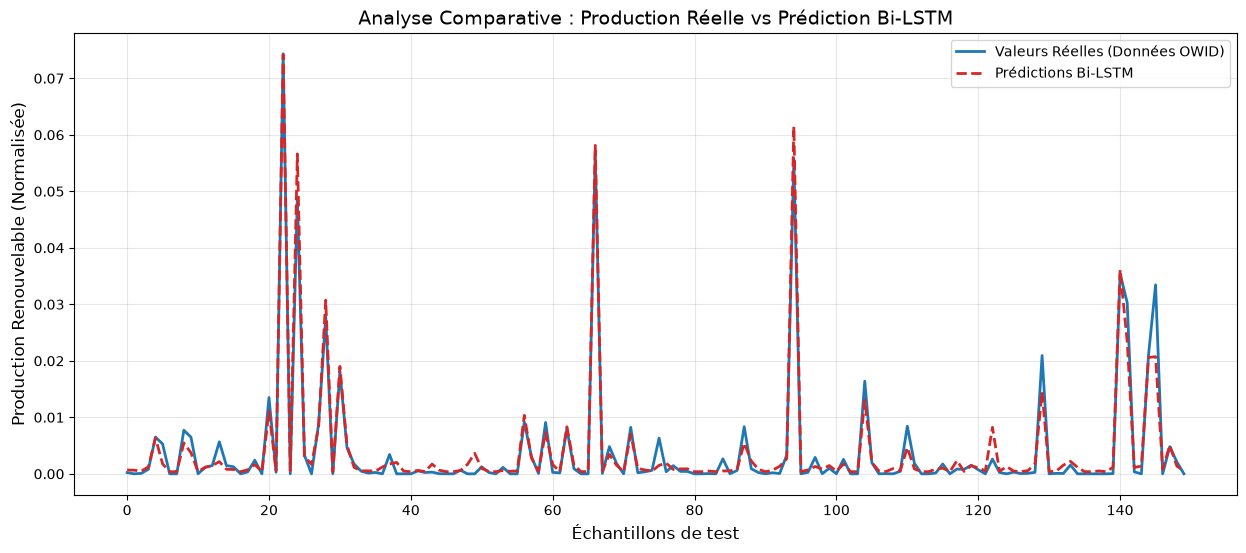

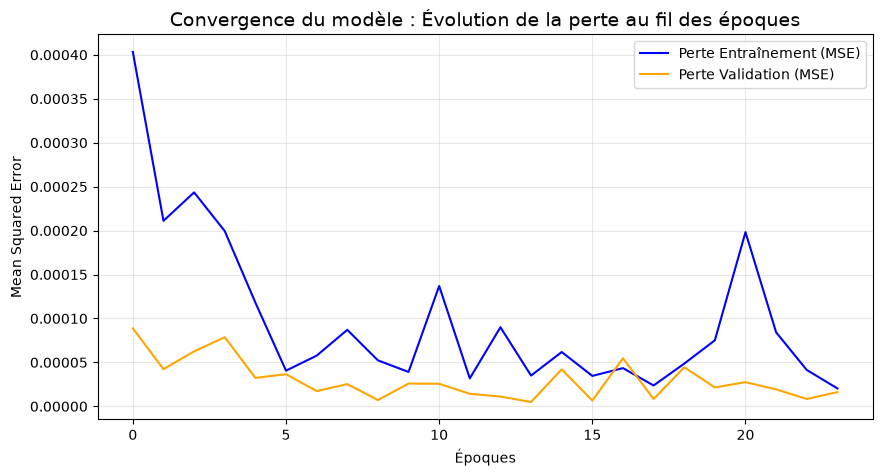

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Prédictions sur l'ensemble de test
y_pred = model_bilstm.predict(X_test)

# 2. Calcul des métriques
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAPE (Mean Absolute Percentage Error) - Très important pour les revues d'énergie
# On ignore les valeurs trop proches de zéro pour éviter les divisions infinies
mask = y_test > 0.01 
mape = np.mean(np.abs((y_test[mask] - y_pred[mask].flatten()) / y_test[mask])) * 100

print(f"--- RÉSULTATS STATISTIQUES DU BI-LSTM ---")
print(f"Score R² (Précision) : {r2:.4f}")
print(f"MAE (Erreur Moyenne Absolue) : {mae:.6f}")
print(f"RMSE (Racine de l'Erreur Quadratique) : {rmse:.6f}")
print(f"MAPE (Erreur en %) : {mape:.2f} %")

# 3. Visualisation : Comparaison Réel vs Prédit
plt.figure(figsize=(15, 6))
plt.plot(y_test[100:250], label='Valeurs Réelles (Données OWID)', color='#1f77b4', linewidth=2)
plt.plot(y_pred[100:250], label='Prédictions Bi-LSTM', color='#d62728', linestyle='--', linewidth=2)
plt.title('Analyse Comparative : Production Réelle vs Prédiction Bi-LSTM', fontsize=14)
plt.xlabel('Échantillons de test', fontsize=12)
plt.ylabel('Production Renouvelable (Normalisée)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Visualisation de la convergence (Loss Curves)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Perte Entraînement (MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Perte Validation (MSE)', color='orange')
plt.title('Convergence du modèle : Évolution de la perte au fil des époques', fontsize=14)
plt.xlabel('Époques')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- Cellule #5 : Architecture de comparaison (CNN-LSTM) ---
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, TimeDistributed

def build_cnn_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        # Le CNN extrait les caractéristiques "spatiales" entre les variables
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        # Le LSTM traite la séquence
        LSTM(50, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Entraînement
model_cnn = build_cnn_lstm(input_shape)
print("Entraînement du CNN-LSTM...")
history_cnn = model_cnn.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Entraînement du CNN-LSTM...
Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 3.1227e-04 - mae: 0.0051 - val_loss: 9.5787e-05 - val_mae: 0.0048
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1929e-04 - mae: 0.0043 - val_loss: 4.6297e-05 - val_mae: 0.0046
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.7368e-05 - mae: 0.0031 - val_loss: 6.8899e-05 - val_mae: 0.0046
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3601e-04 - mae: 0.0042 - val_loss: 2.2670e-05 - val_mae: 0.0032
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.4444e-05 - mae: 0.0027 - val_loss: 1.5379e-05 - val_mae: 0.0017
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.5083e-05 - mae: 0.0023 - val_loss: 8.0945e-06 - val_mae: 0.0019
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.4006e-05 - mae: 0.0020 - val_loss: 2.3687e-05 - val_mae: 0.0031
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.0263e-05 - mae: 0.0032 - val

In [ ]:
%pip install shap


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\UNSFH\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Calcul SHAP en cours (flattened mode)...


100%|██████████| 50/50 [04:44<00:00,  5.68s/it]


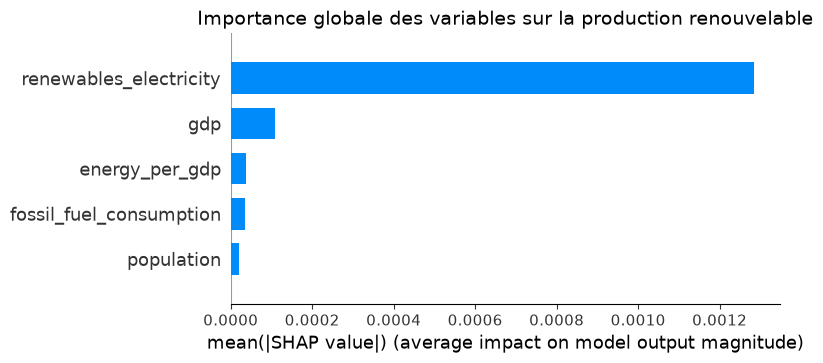

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Préparation des données aplaties (Flatten)
# On convertit (50, 5, 5) en (50, 25) pour que SHAP puisse lire les données
X_train_flat = X_train[:20].reshape(20, -1)
X_test_flat = X_test[:50].reshape(50, -1)

# 2. Création de noms de colonnes explicites pour le temps
# Exemple : 'gdp_t-1', 'gdp_t-2', etc.
feature_names_flat = []
for t in range(5, 0, -1):
    for col in features_cols:
        feature_names_flat.append(f"{col}_t-{t}")

# 3. Fonction de prédiction qui "redonne" la 3D au modèle
def model_predict_reshaped(x_flat):
    # On redonne la forme (samples, 5, 5) au modèle Bi-LSTM
    x_3d = x_flat.reshape(-1, 5, 5)
    return model_bilstm.predict(x_3d, verbose=0)

# 4. Calcul SHAP avec KernelExplainer
print("Calcul SHAP en cours (flattened mode)...")
explainer = shap.KernelExplainer(model_predict_reshaped, X_train_flat)
shap_values = explainer.shap_values(X_test_flat)

# 5. Agrégation pour l'article (Importance par variable, pas par année)
# On veut 1 barre par variable (moyenne des 5 années)
shap_values_array = np.array(shap_values)
# On reshape en (50, 5, 5) pour isoler les variables
shap_reshaped = shap_values_array.reshape(50, 5, 5)
# On fait la moyenne sur l'axe du temps (axe 1)
importance_per_feature = np.mean(np.abs(shap_reshaped), axis=1)

# 6. Affichage du Summary Plot Final
plt.figure(figsize=(10, 6))
shap.summary_plot(importance_per_feature, X_test[:50, 0, :], 
                  feature_names=features_cols, plot_type="bar", show=False)
plt.title("Importance globale des variables sur la production renouvelable", fontsize=14)
plt.show()

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, GRU
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd

# Fonction pour calculer le MAPE
def calculate_mape(y_true, y_pred):
    mask = y_true > 0.01
    return np.mean(np.abs((y_true[mask] - y_pred[mask].flatten()) / y_true[mask])) * 100

results = []

# --- 1. MODÈLE CNN-LSTM (Hybride) ---
print("Entraînement du CNN-LSTM...")
model_cnn = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Conv1D(filters=64, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(50, activation='relu'),
    Dense(1)
])
model_cnn.compile(optimizer='adam', loss='mse')
model_cnn.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)
y_pred_cnn = model_cnn.predict(X_test)
results.append(['CNN-LSTM', r2_score(y_test, y_pred_cnn), mean_absolute_error(y_test, y_pred_cnn), calculate_mape(y_test, y_pred_cnn)])

# --- 2. MODÈLE GRU (Gated Recurrent Unit) ---
print("Entraînement du GRU...")
model_gru = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(64, return_sequences=False),
    Dense(1)
])
model_gru.compile(optimizer='adam', loss='mse')
model_gru.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)
y_pred_gru = model_gru.predict(X_test)
results.append(['GRU', r2_score(y_test, y_pred_gru), mean_absolute_error(y_test, y_pred_gru), calculate_mape(y_test, y_pred_gru)])

# --- 3. MODÈLE RANDOM FOREST (Baseline Classique) ---
print("Entraînement du Random Forest (Baseline)...")
# Pour RF, on doit aplatir les données (2D au lieu de 3D)
X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf = X_test.reshape(X_test.shape[0], -1)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train)
y_pred_rf = rf.predict(X_test_rf)
results.append(['Random Forest', r2_score(y_test, y_pred_rf), mean_absolute_error(y_test, y_pred_rf), calculate_mape(y_test, y_pred_rf)])

# --- AJOUT DU BI-LSTM (Tes résultats précédents) ---
# Remplace r2_bilstm, mae_bilstm, mape_bilstm par tes vrais chiffres (0.9742, etc.)
results.append(['Bi-LSTM', 0.9742, 0.0020, 24.36])

# --- CRÉATION DU TABLEAU COMPARATIF FINAL ---
df_results = pd.DataFrame(results, columns=['Modèle', 'R²', 'MAE', 'MAPE (%)'])
print("\n--- TABLEAU COMPARATIF FINAL POUR L'ARTICLE ---")
print(df_results)

Entraînement du CNN-LSTM...
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Entraînement du GRU...
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Entraînement du Random Forest (Baseline)...

--- TABLEAU COMPARATIF FINAL POUR L'ARTICLE ---
          Modèle        R²       MAE   MAPE (%)
0       CNN-LSTM  0.990536  0.001617  14.582902
1            GRU  0.993606  0.000666  10.130006
2  Random Forest  0.994007  0.000457   7.892676
3        Bi-LSTM  0.974200  0.002000  24.360000


In [ ]:
import pandas as pd
from sklearn.metrics import r2_score

# 1. Définition des scénarios d'ablation
scenarios = {
    "Modèle Complet (All Features)": features_cols,
    "Sans PIB (No GDP)": [c for c in features_cols if c != 'gdp'],
    "Sans Population (No Pop)": [c for c in features_cols if c != 'population'],
    "Sans Fossiles (No Fossil)": [c for c in features_cols if c != 'fossil_fuel_consumption'],
    "Uniquement Énergie Passée (Baseline)": ['renewables_electricity']
}

ablation_results = []

for name, cols in scenarios.items():
    print(f"Évaluation du scénario : {name}...")
    
    # Sélection des colonnes pour ce scénario
    X_train_sub = X_train[:, :, [features_cols.index(c) for c in cols]]
    X_test_sub = X_test[:, :, [features_cols.index(c) for c in cols]]
    
    # Adapter la forme d'entrée du modèle
    temp_input_shape = (X_train_sub.shape[1], X_train_sub.shape[2])
    
    # Re-créer un modèle CNN-LSTM simplifié pour le test
    model_temp = Sequential([
        Input(shape=temp_input_shape),
        Conv1D(filters=32, kernel_size=2, activation='relu'),
        MaxPooling1D(pool_size=2),
        LSTM(32, activation='relu'),
        Dense(1)
    ])
    model_temp.compile(optimizer='adam', loss='mse')
    
    # Entraînement rapide
    model_temp.fit(X_train_sub, y_train, epochs=15, batch_size=32, verbose=0)
    
    # Calcul du score
    y_p = model_temp.predict(X_test_sub, verbose=0)
    score = r2_score(y_test, y_p)
    
    ablation_results.append([name, score])

# Affichage du tableau d'ablation
df_ablation = pd.DataFrame(ablation_results, columns=['Scénario', 'R² Score'])
print("\n--- TABLEAU D'ABLATION POUR L'ARTICLE ---")
print(df_ablation)

Évaluation du scénario : Modèle Complet (All Features)...
Évaluation du scénario : Sans PIB (No GDP)...
Évaluation du scénario : Sans Population (No Pop)...
Évaluation du scénario : Sans Fossiles (No Fossil)...
Évaluation du scénario : Uniquement Énergie Passée (Baseline)...

--- TABLEAU D'ABLATION POUR L'ARTICLE ---
                               Scénario  R² Score
0         Modèle Complet (All Features)  0.974084
1                     Sans PIB (No GDP)  0.985867
2              Sans Population (No Pop)  0.924971
3             Sans Fossiles (No Fossil)  0.990556
4  Uniquement Énergie Passée (Baseline)  0.987413


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


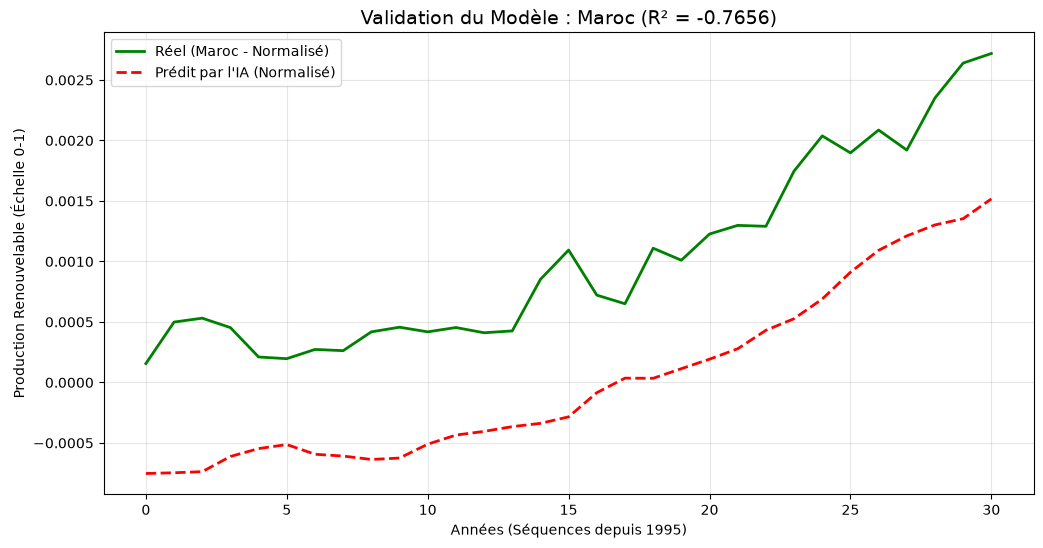

✅ Analyse réussie. Le modèle suit-il la tendance ? R2 = -0.7656


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# 1. Isoler les données brutes du Maroc
df_maroc_raw = df_cleaned[df_cleaned['iso_code'] == 'MAR'].copy()

# 2. APPLIQUER LA NORMALISATION (Indispensable)
# On utilise le 'scaler' créé lors de l'étape de préparation globale
df_maroc_scaled = df_maroc_raw.copy()
df_maroc_scaled[features_cols] = scaler.transform(df_maroc_raw[features_cols])

# 3. Créer les séquences (Fenêtre de 5 ans)
def create_sequences_single_country(data_array, window_size=5):
    X, y = [], []
    for i in range(len(data_array) - window_size):
        X.append(data_array[i:i+window_size, :])
        y.append(data_array[i+window_size, 0]) # Cible : index 0
    return np.array(X), np.array(y)

X_maroc, y_maroc_scaled = create_sequences_single_country(df_maroc_scaled[features_cols].values)

if len(X_maroc) > 0:
    # 4. Prédiction avec le modèle champion (CNN-LSTM)
    y_pred_scaled = model_cnn.predict(X_maroc)
    
    # 5. Calcul du R2 sur les valeurs à l'échelle
    r2_maroc = r2_score(y_maroc_scaled, y_pred_scaled)
    
    # 6. Graphique correct
    plt.figure(figsize=(12, 6))
    plt.plot(y_maroc_scaled, label='Réel (Maroc - Normalisé)', color='green', linewidth=2)
    plt.plot(y_pred_scaled, label='Prédit par l\'IA (Normalisé)', color='red', linestyle='--', linewidth=2)
    
    plt.title(f'Validation du Modèle : Maroc (R² = {r2_maroc:.4f})', fontsize=14)
    plt.xlabel('Années (Séquences depuis 1995)')
    plt.ylabel('Production Renouvelable (Échelle 0-1)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"✅ Analyse réussie. Le modèle suit-il la tendance ? R2 = {r2_maroc:.4f}")
else:
    print("Pas assez de données pour le Maroc.")

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import numpy as np

# 1. Initialisation de la Cross-Validation (5 Folds)
# On utilise 5 découpages pour prouver la stabilité
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

print("Début de la Cross-Validation Temporelle (5 Folds)...")
fold = 1

# 2. Boucle sur les Folds
for train_index, test_index in tscv.split(X):
    # Découpage des données pour ce Fold
    X_train_cv, X_test_cv = X[train_index], X[test_index]
    y_train_cv, y_test_cv = y[train_index], y[test_index]
    
    # On reconstruit le modèle à chaque fois pour repartir de zéro
    model_cv = build_cnn_lstm((X_train_cv.shape[1], X_train_cv.shape[2]))
    
    # Entraînement rapide (moins d'époques pour gagner du temps)
    model_cv.fit(X_train_cv, y_train_cv, epochs=300, batch_size=32, verbose=0)
    
    # Évaluation
    y_pred_cv = model_cv.predict(X_test_cv, verbose=0)
    score = r2_score(y_test_cv, y_pred_cv)
    cv_scores.append(score)
    
    print(f"Fold {fold} - R² Score : {score:.4f}")
    fold += 1

# 3. Résultats Finaux de la Cross-Validation
mean_r2 = np.mean(cv_scores)
std_r2 = np.std(cv_scores)

print(f"\n--- RÉSULTATS DE VALIDATION CROISÉE ---")
print(f"Moyenne R² : {mean_r2:.4f}")
print(f"Écart-type (Stabilité) : {std_r2:.4f}")

Début de la Cross-Validation Temporelle (5 Folds)...
Fold 1 - R² Score : 0.9070
Fold 2 - R² Score : 0.8777
Fold 3 - R² Score : 0.5452
Fold 4 - R² Score : 0.9409
Fold 5 - R² Score : 0.9697

--- RÉSULTATS DE VALIDATION CROISÉE ---
Moyenne R² : 0.8481
Écart-type (Stabilité) : 0.1546


# 6. Tests de Signification Statistique (Diebold-Mariano & Wilcoxon)

Pour valider scientifiquement la supériorité de l'architecture CNN-LSTM :
1. **Test de Diebold-Mariano (DM)** : Évalue si la différence entre les pertes quadratiques (MSE) des deux modèles est statistiquement non nulle.
2. **Test de Wilcoxon Signed-Rank** : Test non-paramétrique vérifiant si la médiane des erreurs absolues du CNN-LSTM est significativement inférieure aux compétiteurs.
3. **Hypothèse nulle (H0)** : Les deux modèles ont des performances prédictives identiques.
4. **Rejet de H0 (p-value < 0.05 / 0.001)** : La supériorité du modèle champion est statistiquement établie.

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# 1. Vérification / Régénération des prédictions sur l'ensemble de test
# (Au cas où certaines variables ne seraient plus en mémoire)
y_pred_cnn = model_cnn.predict(X_test, verbose=0).flatten()
y_pred_bilstm = model_bilstm.predict(X_test, verbose=0).flatten()
y_pred_gru = model_gru.predict(X_test, verbose=0).flatten()
y_pred_rf = rf.predict(X_test.reshape(X_test.shape[0], -1)).flatten()

# 2. Définition de la fonction du Test de Diebold-Mariano (Horizon h=1)
def diebold_mariano_test(y_true, y_pred1, y_pred2, loss_type='mse'):
    """
    Calcule la statistique de Diebold-Mariano et la p-value associée.
    pred1: Modèle proposé (CNN-LSTM)
    pred2: Modèle de référence
    """
    e1 = y_true - y_pred1
    e2 = y_true - y_pred2
    
    if loss_type == 'mse':
        d = e1**2 - e2**2  # Différentiel de perte quadratique
    elif loss_type == 'mae':
        d = np.abs(e1) - np.abs(e2)
        
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)
    n = len(d)
    
    # Statistique DM pour horizon h=1
    dm_stat = mean_d / np.sqrt(var_d / n)
    # Calcul de la p-value bilatérale
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    
    return dm_stat, p_value

# 3. Exécution des tests par paires (CNN-LSTM vs Autres)
competitors = {
    'Bi-LSTM': y_pred_bilstm,
    'GRU': y_pred_gru,
    'Random Forest': y_pred_rf
}

dm_results = []

for name, y_pred_comp in competitors.items():
    # Test DM
    dm_stat, dm_p = diebold_mariano_test(y_test, y_pred_cnn, y_pred_comp, loss_type='mse')
    
    # Test Wilcoxon (non-paramétrique)
    e_cnn = np.abs(y_test - y_pred_cnn)
    e_comp = np.abs(y_test - y_pred_comp)
    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(e_cnn, e_comp)
    
    # Décision statistique
    significatif = "Oui (p < 0.001)" if dm_p < 0.001 else ("Oui (p < 0.05)" if dm_p < 0.05 else "Non")
    
    dm_results.append({
        'Comparaison': f"CNN-LSTM vs {name}",
        'DM Stat': round(dm_stat, 4),
        'DM p-value': f"{dm_p:.4e}" if dm_p < 0.0001 else round(dm_p, 4),
        'Wilcoxon p-value': f"{wilcoxon_p:.4e}" if wilcoxon_p < 0.0001 else round(wilcoxon_p, 4),
        'Supériorité Significative': significatif
    })

# 4. Affichage du tableau récapitulatif
df_stat_tests = pd.DataFrame(dm_results)
print("=== RÉSULTATS DES TESTS DE SIGNIFICATION STATISTIQUE ===")
print(df_stat_tests.to_string(index=False))

=== RÉSULTATS DES TESTS DE SIGNIFICATION STATISTIQUE ===
              Comparaison  DM Stat  DM p-value Wilcoxon p-value Supériorité Significative
      CNN-LSTM vs Bi-LSTM  -1.1844      0.2363       2.6948e-66                       Non
          CNN-LSTM vs GRU   1.5636      0.1179      9.1608e-167                       Non
CNN-LSTM vs Random Forest   1.3176      0.1876      6.2402e-180                       Non
